In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

%matplotlib inline

In [2]:
df = pd.read_csv('apartment_rental_listings.csv')
df.head()

,Property,Property Score,Unit Type,Location,Date Posted,Monthly Rent
0,The Overlook at Shadyside,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)"
1,Brookside Manor,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)"
2,Silverleaf Apartments,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)"
3,The Fairmount,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)"
4,Station Square Residences,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)"


In [3]:
df.shape

(870, 6)

In [4]:
df.dtypes

Property              str
Property Score    float64
Unit Type             str
Location              str
Date Posted           str
Monthly Rent          str
dtype: object

In [6]:
df_edit = df.copy()

In [7]:
df_edit.head()

,Property,Property Score,Unit Type,Location,Date Posted,Monthly Rent
0,The Overlook at Shadyside,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)"
1,Brookside Manor,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)"
2,Silverleaf Apartments,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)"
3,The Fairmount,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)"
4,Station Square Residences,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)"


In [8]:
# Drop a column in place
df_edit.drop('Property', axis=1, inplace=True)

In [9]:
df_edit.head()

,Property Score,Unit Type,Location,Date Posted,Monthly Rent
0,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)"
1,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)"
2,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)"
3,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)"
4,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)"


In [14]:
#df_edit.rename(columns={'Property Score' : 'property_score'}, inplace=True)
new_cols = []
for col in df_edit.columns:
    new_cols.append(col.lower().replace(' ', '_'))

#print(new_cols)
df_edit.columns = new_cols
df_edit.head()

,property_score,unit_type,location,date_posted,monthly_rent
0,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)"
1,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)"
2,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)"
3,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)"
4,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)"


In [15]:
df.isna()

,Property,Property Score,Unit Type,Location,Date Posted,Monthly Rent
0,False,True,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,True,False,False,False,False
...,...,...,...,...,...,...
865,False,False,False,False,False,False
866,False,False,False,False,False,False
867,False,False,False,False,False,False
868,False,False,False,False,False,False


<Axes: >

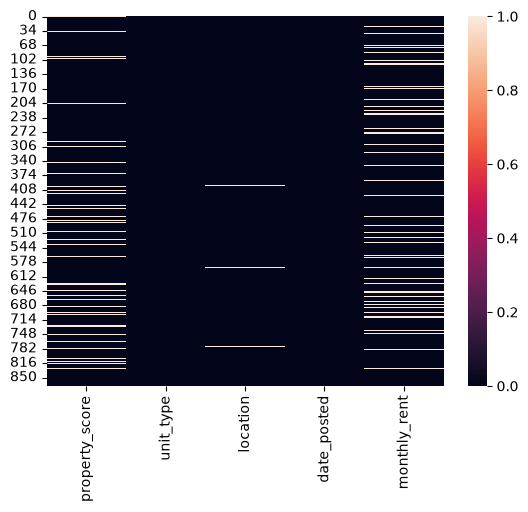

In [16]:
sn.heatmap(df_edit.isna())

In [17]:
# Make up new columns
df_edit['date_posted_days'] = 0
df_edit.head()

,property_score,unit_type,location,date_posted,monthly_rent,date_posted_days
0,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)",0
1,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)",0
2,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)",0
3,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)",0
4,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)",0


In [18]:
df_edit.dtypes

property_score      float64
unit_type               str
location                str
date_posted             str
monthly_rent            str
date_posted_days      int64
dtype: object

In [19]:
df_edit['date_posted'].value_counts()

date_posted
30d+    194
2d      121
3d       87
4d       55
1d       50
10d      48
5d       47
9d       34
6d       30
12d      30
7d       29
8d       27
11d      22
14d      19
20d      16
13d      14
24d      12
16d      12
28d       8
18d       7
26d       4
21d       4
Name: count, dtype: int64

In [24]:
def clean_date_posted(date_posted):
    # Check if the data_posted is missing.  If missing, return 0 as a placeholder
    if pd.isna(date_posted):
        return 0
    else:
        # If not missing, remove + and "d" and return an integer
        return int(date_posted.lower().replace('+', '').replace('d', ''))

In [26]:
clean_date_posted("30+d")

30

In [29]:
for idx, row in df_edit.iterrows():
    df_edit.at[idx, 'date_posted_days'] = clean_date_posted(row['date_posted'])

df_edit.head()

,property_score,unit_type,location,date_posted,monthly_rent,date_posted_days
0,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)",3
1,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)",30
2,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)",4
3,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)",2
4,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)",26


In [31]:
# Update using lambda notation
df_edit['date_posted_days2'] = df_edit['date_posted'].apply(lambda x : clean_date_posted(x))

In [32]:
df_edit.head()

,property_score,unit_type,location,date_posted,monthly_rent,date_posted_days,date_posted_days2
0,NaN,Two Bedroom Apartment Home,"Alpharetta, GA",3d,"$1,400 - $1,825 (Landlord est.)",3,3
1,3.2,2BD/2BA,"Birmingham, AL",30d+,"$1,200 - $1,750 (Landlord est.)",30,30
2,2.7,Studio (Utilities Included),"Seattle, WA",4d,"$1,300 - $1,650 (Landlord est.)",4,4
3,4.7,3 Bedroom Townhouse,"State College, PA",2d,"$1,750 - $2,200 (Landlord est.)",2,2
4,NaN,1 Bedroom Apartment,"Farmington Hills, MI",26d,"$950 - $1,300 (RentPulse est.)",26,26


In [33]:
df_edit.drop('date_posted_days2', axis=1, inplace=True)

In [34]:
df_edit.drop('date_posted', axis=1, inplace=True)

In [35]:
df_edit.head()

,property_score,unit_type,location,monthly_rent,date_posted_days
0,NaN,Two Bedroom Apartment Home,"Alpharetta, GA","$1,400 - $1,825 (Landlord est.)",3
1,3.2,2BD/2BA,"Birmingham, AL","$1,200 - $1,750 (Landlord est.)",30
2,2.7,Studio (Utilities Included),"Seattle, WA","$1,300 - $1,650 (Landlord est.)",4
3,4.7,3 Bedroom Townhouse,"State College, PA","$1,750 - $2,200 (Landlord est.)",2
4,NaN,1 Bedroom Apartment,"Farmington Hills, MI","$950 - $1,300 (RentPulse est.)",26


In [36]:
df_edit['location'].value_counts()

location
Ithaca, NY            18
San Francisco, CA     17
State College, PA     16
Akron, OH             16
Sacramento, CA        15
                      ..
Philadelphia, PA       5
Central New Jersey     5
Multiple Locations     5
Northern Virginia      4
Lehigh Valley          2
Name: count, Length: 83, dtype: int64

In [37]:
df_edit.drop('location', axis=1, inplace=True)

In [38]:
df_edit.head()

,property_score,unit_type,monthly_rent,date_posted_days
0,NaN,Two Bedroom Apartment Home,"$1,400 - $1,825 (Landlord est.)",3
1,3.2,2BD/2BA,"$1,200 - $1,750 (Landlord est.)",30
2,2.7,Studio (Utilities Included),"$1,300 - $1,650 (Landlord est.)",4
3,4.7,3 Bedroom Townhouse,"$1,750 - $2,200 (Landlord est.)",2
4,NaN,1 Bedroom Apartment,"$950 - $1,300 (RentPulse est.)",26


In [39]:
df_edit['rent_lower'] = 0
df_edit['rent_upper'] = 0
df_edit['source'] = ''
df_edit.head()

,property_score,unit_type,monthly_rent,date_posted_days,rent_lower,rent_upper,source
0,NaN,Two Bedroom Apartment Home,"$1,400 - $1,825 (Landlord est.)",3,0,0,
1,3.2,2BD/2BA,"$1,200 - $1,750 (Landlord est.)",30,0,0,
2,2.7,Studio (Utilities Included),"$1,300 - $1,650 (Landlord est.)",4,0,0,
3,4.7,3 Bedroom Townhouse,"$1,750 - $2,200 (Landlord est.)",2,0,0,
4,NaN,1 Bedroom Apartment,"$950 - $1,300 (RentPulse est.)",26,0,0,


In [61]:
import re

def monthly_rent_split(monthly_rent):
    if pd.isna(monthly_rent):
        return 0, 0, 'unknown'
    else:
        rent_range = ''
        data_source = ''
        temp = monthly_rent.split('(')
        #print(temp)
        rent_range = temp[0].replace(',', '').replace(' ', '').replace("$", '').strip()
        # Replace non-numerical characters using regular expressions
        rent_range = re.sub(r"[^\d]+", "|", rent_range)
        # Now that i have a known character, I could split the range again
        rent_range_lower = int(rent_range.split("|")[0])
        rent_range_upper = int(rent_range.split("|")[1])
        data_source = temp[1].replace(')', '').lower()
        #print(rent_range)
        #print(data_source)
        return rent_range_lower, rent_range_upper, data_source
        

In [62]:
monthly_rent_split("950 - 1,300 (RentPulse est.)")

(950, 1300, 'rentpulse est.')

In [63]:
for idx, row in df_edit.iterrows():
    #print(row['monthly_rent'])
    l, u, s = monthly_rent_split(row['monthly_rent'])
    df_edit.at[idx, 'rent_lower'] = l
    df_edit.at[idx, 'rent_upper'] = u
    df_edit.at[idx, 'source'] = s
    #print(l, u, s)
    #break

In [64]:
df_edit.head()

,property_score,unit_type,monthly_rent,date_posted_days,rent_lower,rent_upper,source
0,NaN,Two Bedroom Apartment Home,"$1,400 - $1,825 (Landlord est.)",3,1400,1825,landlord est.
1,3.2,2BD/2BA,"$1,200 - $1,750 (Landlord est.)",30,1200,1750,landlord est.
2,2.7,Studio (Utilities Included),"$1,300 - $1,650 (Landlord est.)",4,1300,1650,landlord est.
3,4.7,3 Bedroom Townhouse,"$1,750 - $2,200 (Landlord est.)",2,1750,2200,landlord est.
4,NaN,1 Bedroom Apartment,"$950 - $1,300 (RentPulse est.)",26,950,1300,rentpulse est.


In [67]:
df_edit['property_score'].isna().sum()

np.int64(79)

In [68]:
df_edit.isna().sum()

property_score       79
unit_type             0
monthly_rent        104
date_posted_days      0
rent_lower            0
rent_upper            0
source                0
dtype: int64

In [70]:
df = pd.read_csv('diabetes.csv')
df.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,29.0,38.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,46.0,48.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,49.0,57.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,33.0,38.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,44.0,41.0


<Axes: >

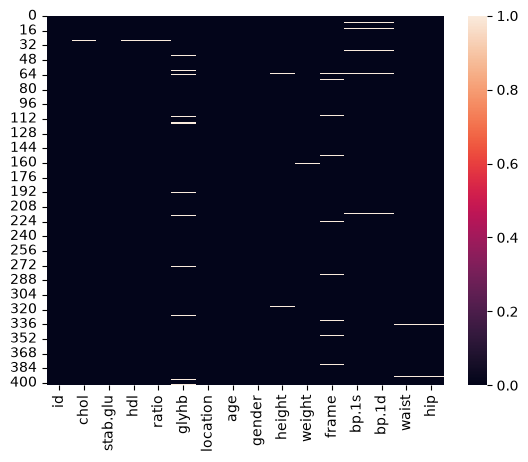

In [71]:
sn.heatmap(df.isnull())

In [72]:
df.isnull().sum()

id           0
chol         1
stab.glu     0
hdl          1
ratio        1
glyhb       13
location     0
age          0
gender       0
height       5
weight       1
frame       12
bp.1s        5
bp.1d        5
waist        2
hip          2
dtype: int64

In [73]:
df.shape

(403, 16)

In [74]:
13/403

0.03225806451612903

In [75]:
df.dropna(inplace=True)
df.shape

(367, 16)

In [76]:
(403 - 367) / 403

0.08933002481389578

In [77]:
# Fixing Distributions

df_edit.head()

,property_score,unit_type,monthly_rent,date_posted_days,rent_lower,rent_upper,source
0,NaN,Two Bedroom Apartment Home,"$1,400 - $1,825 (Landlord est.)",3,1400,1825,landlord est.
1,3.2,2BD/2BA,"$1,200 - $1,750 (Landlord est.)",30,1200,1750,landlord est.
2,2.7,Studio (Utilities Included),"$1,300 - $1,650 (Landlord est.)",4,1300,1650,landlord est.
3,4.7,3 Bedroom Townhouse,"$1,750 - $2,200 (Landlord est.)",2,1750,2200,landlord est.
4,NaN,1 Bedroom Apartment,"$950 - $1,300 (RentPulse est.)",26,950,1300,rentpulse est.


<Axes: xlabel='rent_lower', ylabel='Count'>

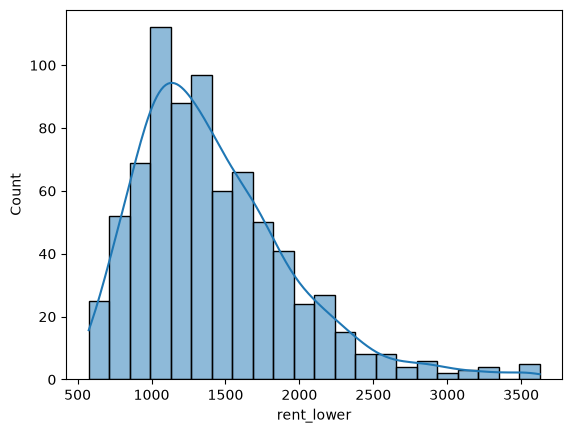

In [79]:
sn.histplot(df_edit.query('rent_lower != 0')['rent_lower'], kde=True)

In [80]:
import math

df_edit['rent_lower_sqrt'] = df_edit['rent_lower'].apply(lambda x : math.sqrt(x))
df_edit.head()

,property_score,unit_type,monthly_rent,date_posted_days,rent_lower,rent_upper,source,rent_lower_sqrt
0,NaN,Two Bedroom Apartment Home,"$1,400 - $1,825 (Landlord est.)",3,1400,1825,landlord est.,37.416574
1,3.2,2BD/2BA,"$1,200 - $1,750 (Landlord est.)",30,1200,1750,landlord est.,34.641016
2,2.7,Studio (Utilities Included),"$1,300 - $1,650 (Landlord est.)",4,1300,1650,landlord est.,36.055513
3,4.7,3 Bedroom Townhouse,"$1,750 - $2,200 (Landlord est.)",2,1750,2200,landlord est.,41.833001
4,NaN,1 Bedroom Apartment,"$950 - $1,300 (RentPulse est.)",26,950,1300,rentpulse est.,30.822070


<Axes: xlabel='rent_lower_sqrt', ylabel='Count'>

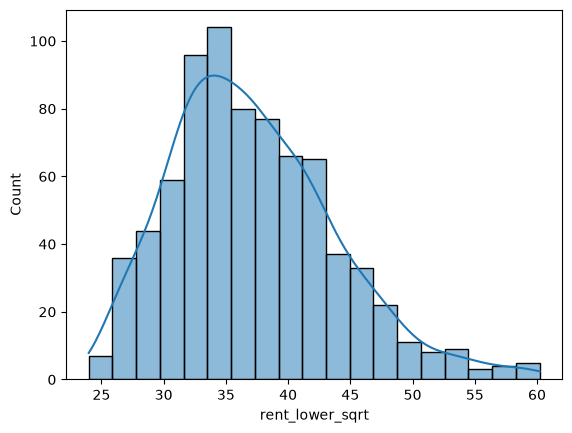

In [81]:
sn.histplot(df_edit.query('rent_lower != 0')['rent_lower_sqrt'], kde=True)

<Axes: xlabel='rent_lower_log', ylabel='Count'>

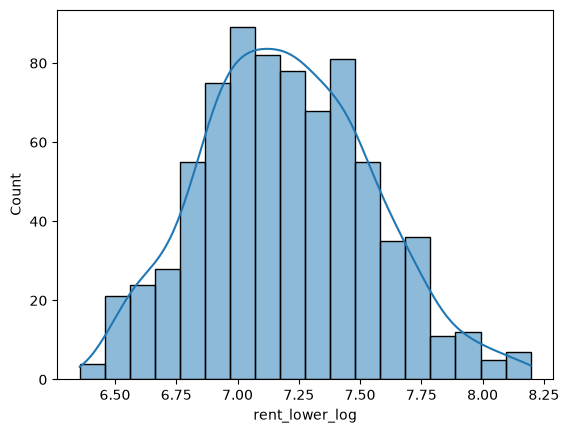

In [83]:
df_edit['rent_lower_log'] = df_edit['rent_lower'].apply(lambda x : math.log(x + 1))
sn.histplot(df_edit.query('rent_lower > 0')['rent_lower_log'], kde=True)

<Axes: xlabel='rent_lower', ylabel='Count'>

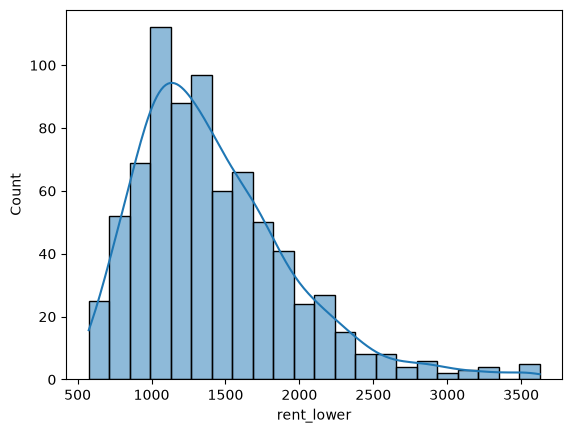

In [84]:
sn.histplot(df_edit.query('rent_lower > 0')['rent_lower'], kde=True)

In [85]:
from sklearn.preprocessing import StandardScaler

In [87]:
scaler = StandardScaler()

df_edit[['rent_lower_scaled']] = scaler.fit_transform(df_edit[['rent_lower']])

In [90]:
df_edit[['rent_lower', 'rent_lower_scaled']]

,rent_lower,rent_lower_scaled
0,1400,0.214485
1,1200,-0.081181
2,1300,0.066652
3,1750,0.731901
4,950,-0.450763
...,...,...
865,2025,1.138441
866,1050,-0.302930
867,1075,-0.265972
868,1050,-0.302930


<Axes: xlabel='rent_lower_scaled', ylabel='Count'>

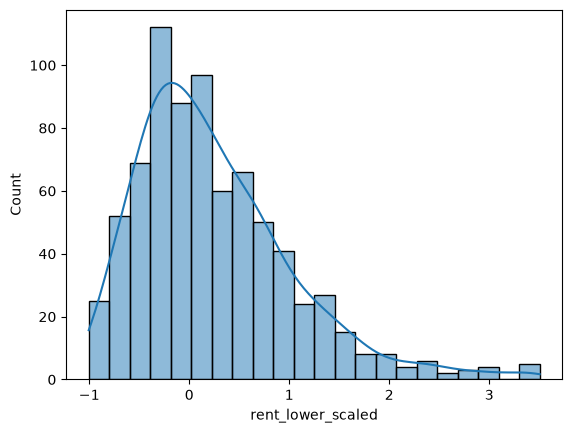

In [91]:
sn.histplot(df_edit.query('rent_lower > 0')['rent_lower_scaled'], kde=True)

<Axes: xlabel='rent_lower_minmax', ylabel='Count'>

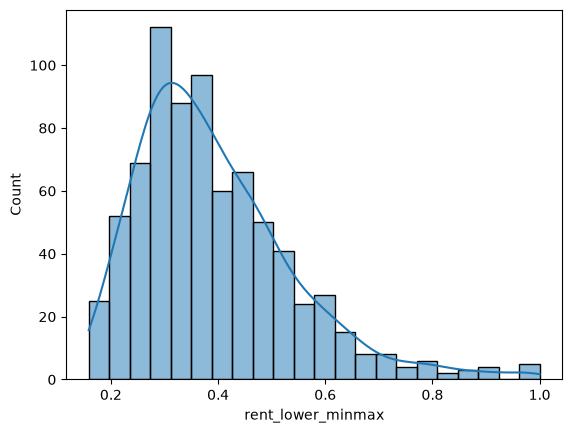

In [94]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_edit[['rent_lower_minmax']] = scaler.fit_transform(df_edit[['rent_lower']])
sn.histplot(df_edit.query('rent_lower > 0')['rent_lower_minmax'], kde=True)